#Phase 2: Advanced Denial Risk Prediction Model

This executes Phase 2 of the Denial Risk. Building upon the initial exploratory data analysis and basic preprocessing from Phase 1, this code transitions that stuff into advanced predictive modeling.

We are changing simple baseline algorithms (like Logistic Regression or standard Decision Trees) in favor of high-performance techniques:
1. **CatBoostClassifier**: An advanced gradient boosting algorithm that natively handles categorical features without the need for extensive one-hot encoding, making it useful and powerful for medical/billing datasets.
2. **HistGradientBoostingClassifier**: An advanced algorithm that discretizes continuous features into histograms. This significantly reduces the number of split points the model needs to evaluate, providing very fast speeds and accuracy on complex data structures, kind of how we split dimensions to understand fields better.

In [ ]:
!pip install catboost -q

## Environment Setup & Dependencies
We initialize our environment by importing the necessary libraries for data manipulation, visualization, machine learning, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import HistGradientBoostingClassifier
from catboost import CatBoostClassifier
import warnings

import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

## Data Loading & Description
We load the dataset into memory. We then define our target column variable.

In [ ]:
import pandas as pd
import numpy as np

dataPath = 'denial_risk.csv'
df = pd.read_csv(dataPath)

columnMapping = {
    'denial_outcome': 'denialOutcome',
    'requested_amount_usd': 'requestedAmountUsd',
    'payer_policy_strictness': 'payerPolicyStrictness',
    'note_completeness_score': 'noteCompletenessScore',
    'policy_match_score': 'policyMatchScore',
    'clinical_note_present': 'clinicalNotePresent',
    'project_denial_reason': 'projectDenialReason',
    'detailed_denial_reason': 'detailedDenialReason'
}
df = df.rename(columns=columnMapping)

targetCol = 'denialOutcome'

df.loc[df[targetCol] == 'Approved', 'projectDenialReason'] = np.nan
df.loc[df[targetCol] == 'Approved', 'detailed_denial_reason'] = np.nan

print(df.shape)
display(df.describe(include='all'))
print(df.isnull().sum())

display(df.head())

(200000, 45)


,case_id,payer_family,payer_name,plan_type,patient_age,age_group,provider_specialty,diagnosis_category,diagnosis_code,request_type,...,policyMatchScore,noteCompletenessScore,payerPolicyStrictness,requested_units,requestedAmountUsd,denial_probability_true_synthetic,denialOutcome,detailedDenialReason,projectDenialReason,detailed_denial_reason
count,200000,200000,197665,200000,200000.000000,200000,194928,200000,193050,200000,...,195964.000000,195090.000000,200000.000000,197012.000000,200000.000000,200000.000000,200000,200000,51367,0.0
unique,200000,5,9,12,NaN,6,12,13,111753,7,...,NaN,NaN,NaN,NaN,NaN,NaN,2,10,6,NaN
top,PA-00199984,Commercial,Kaiser,Traditional Medicare,NaN,50-64,Rheumatology,Chronic Pain,N81.62,Medication,...,NaN,NaN,NaN,NaN,NaN,NaN,Approved,approved,medical_necessity_not_established,NaN
freq,1,72110,22174,23912,NaN,65241,16552,15644,10,51951,...,NaN,NaN,NaN,NaN,NaN,NaN,148633,148633,16641,NaN
mean,NaN,NaN,NaN,NaN,61.826045,NaN,NaN,NaN,NaN,NaN,...,1.752283,2.050584,0.545910,9.392408,2894.043925,0.256601,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,17.115538,NaN,NaN,NaN,NaN,NaN,...,32.663643,37.931466,0.181114,12.682584,5284.746280,0.210677,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-5.000000,NaN,NaN,NaN,NaN,NaN,...,-0.200000,-0.100000,0.050000,1.000000,33.000000,0.021400,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,...,0.572000,0.498000,0.422000,1.000000,723.660000,0.097500,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,62.000000,NaN,NaN,NaN,NaN,NaN,...,0.693000,0.613000,0.546000,2.000000,1364.830000,0.181000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,74.000000,NaN,NaN,NaN,NaN,NaN,...,0.804000,0.723000,0.671000,21.000000,3005.945000,0.355100,NaN,NaN,NaN,NaN


case_id                                     0
payer_family                                0
payer_name                               2335
plan_type                                   0
patient_age                                 0
age_group                                   0
provider_specialty                       5072
diagnosis_category                          0
diagnosis_code                           6950
request_type                                0
procedure_code                          56109
ndc_code                               150923
site_of_care                                0
network_status                           3576
urgency                                     0
prior_auth_required                         0
pa_form_submitted                           0
clinicalNotePresent                         0
diagnosis_code_present                      0
procedure_code_present                      0
lab_report_attached                         0
referral_attached                 

,case_id,payer_family,payer_name,plan_type,patient_age,age_group,provider_specialty,diagnosis_category,diagnosis_code,request_type,...,policyMatchScore,noteCompletenessScore,payerPolicyStrictness,requested_units,requestedAmountUsd,denial_probability_true_synthetic,denialOutcome,detailedDenialReason,projectDenialReason,detailed_denial_reason
0,PA-00000001,Commercial,CMS-Medicare,Self-funded,82,75+,Orthopedics,Autoimmune,NaN,Imaging,...,0.670,0.886,0.421,1.0,344.71,0.0736,Denied,medical_necessity_not_established,medical_necessity_not_established,NaN
1,PA-00000002,Medicare FFS,Humana,Traditional Medicare,68,65-74,Primary Care,Gastrointestinal,Z26.79,Medication,...,0.828,0.612,0.456,27.0,633.80,0.0917,Approved,approved,NaN,NaN
2,PA-00000003,Medicaid Managed Care,Kaiser,Medicaid-MCO,78,75+,Endocrinology,Dermatologic,Z83.11,Medication,...,0.612,0.592,0.265,30.0,388.26,0.1898,Approved,approved,NaN,NaN
3,PA-00000004,Commercial,Kaiser,Self-funded,57,50-64,Dermatology,Diabetes,E81.56,Infusion,...,0.863,0.765,0.477,1.0,2165.03,0.0701,Denied,medical_necessity_not_established,medical_necessity_not_established,NaN
4,PA-00000005,Medicare Advantage,UnitedHealthcare,MA-PPO,42,35-49,Dermatology,Neurologic,G88.41,Imaging,...,0.596,NaN,0.295,2.0,507.16,0.2687,Approved,approved,NaN,NaN


## Exploratory Data Analysis & Visualization
Before modeling, we must understand the class balance of our target variable and the collinearity of our numerical features. Imbalanced datasets are common in denial risk prediction and heavily influence our evaluation metrics.

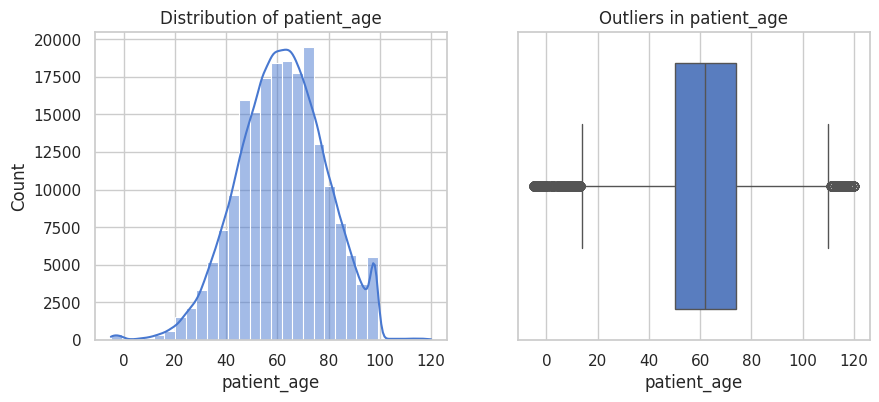

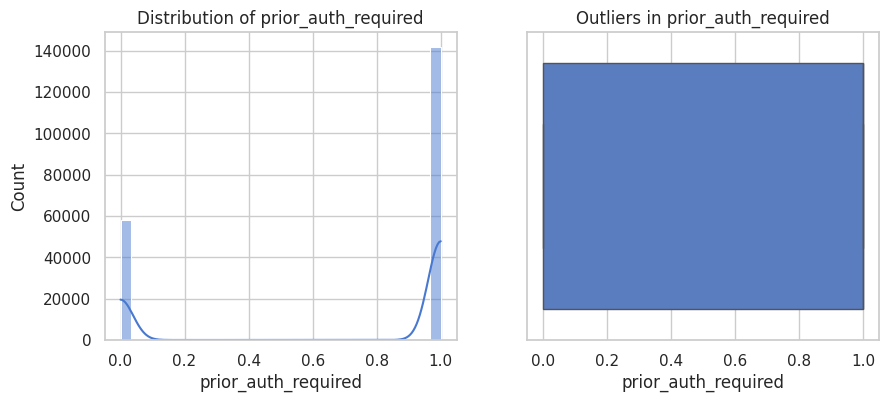

In [ ]:
numericalCols = df.select_dtypes(include=['int64', 'float64']).columns[:2]

for col in numericalCols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()


### Denial Reason Distribution
THis explains why claims are denied, and is critical for operational improvement. We analyze the `project_denial_reason` to identify the most frequent friction points.

/tmp/ipykernel_28718/580937282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=denialData, y='projectDenialReason', palette='magma', order=denialData['projectDenialReason'].value_counts().index)


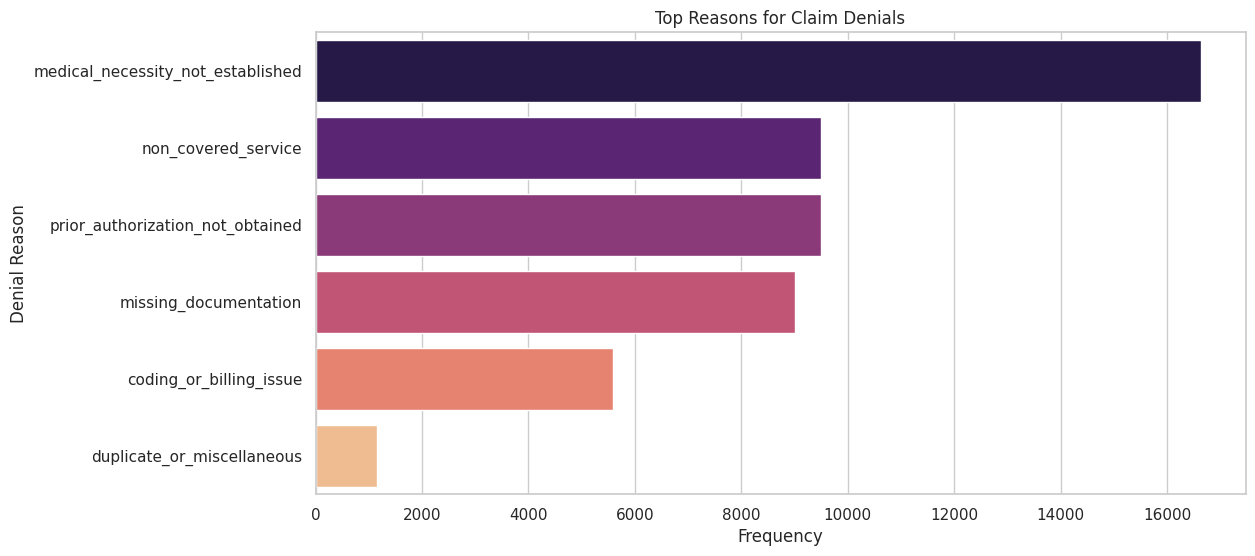

In [ ]:
plt.figure(figsize=(12, 6))
denialData = df[df[targetCol] == 'Denied']
if not denialData.empty:
    sns.countplot(data=denialData, y='projectDenialReason', palette='magma', order=denialData['projectDenialReason'].value_counts().index)
    plt.title('Top Reasons for Claim Denials')
    plt.xlabel('Frequency')
    plt.ylabel('Denial Reason')
    plt.show()
else:
    print('No denied claims found in the dataset to analyze.')

### Behavioral Analysis: Payer Strictness & Scores
We explore how internal scores and payer behaviors correlate with denial outcomes using distribution plots.

/tmp/ipykernel_28718/2468366066.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=targetCol, y='payerPolicyStrictness', palette='vlag')


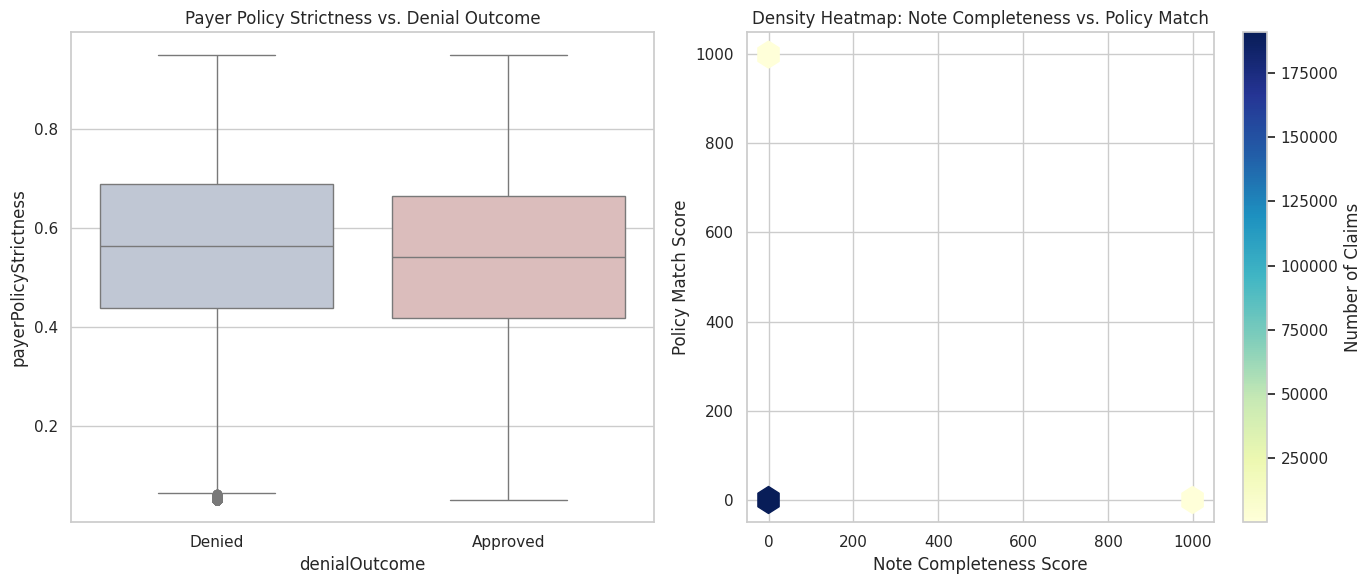

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x=targetCol, y='payerPolicyStrictness', palette='vlag')
plt.title('Payer Policy Strictness vs. Denial Outcome')

plt.subplot(1, 2, 2)
plotDf = df.dropna(subset=['noteCompletenessScore', 'policyMatchScore'])

hb = plt.hexbin(plotDf['noteCompletenessScore'],
                plotDf['policyMatchScore'],
                gridsize=20,
                cmap='YlGnBu',
                mincnt=1)
plt.colorbar(hb, label='Number of Claims')
plt.title('Density Heatmap: Note Completeness vs. Policy Match')
plt.xlabel('Note Completeness Score')
plt.ylabel('Policy Match Score')

plt.tight_layout()
plt.show()

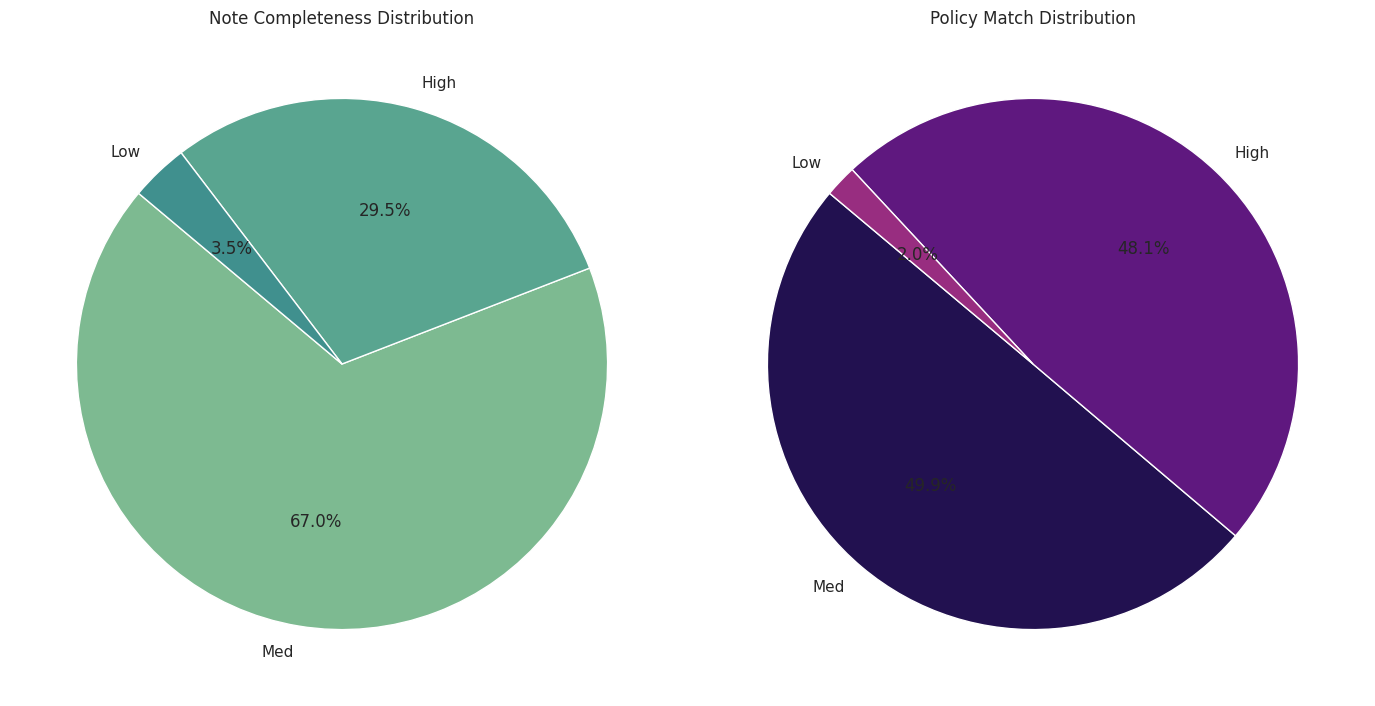

In [ ]:
plt.figure(figsize=(14, 7))

# Helper to bin the scores
def binVals(s):
    return pd.cut(s, bins=[0, 0.3, 0.7, 1.0], labels=['Low', 'Med', 'High'], include_lowest=True)

# Note Completeness Pie
plt.subplot(1, 2, 1)
ncDist = binVals(df['noteCompletenessScore']).value_counts()
plt.pie(ncDist, labels=ncDist.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('crest'))
plt.title('Note Completeness Distribution')

# Policy Match Pie
plt.subplot(1, 2, 2)
pmDist = binVals(df['policyMatchScore']).value_counts()
plt.pie(pmDist, labels=pmDist.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('magma'))
plt.title('Policy Match Distribution')

plt.tight_layout()
plt.show()

##Data Preprocessing
Medical and billing datasets are rarely clean. This preprocessing pipeline isolates the target variable, detects numerical versus categorical columns, handles missing values logically (medians for numbers, modes for categories), scales the data, and securely encodes classes without data leakage.

In [ ]:
df = df.drop_duplicates()

leakageCols = ['detailedDenialReason', 'projectDenialReason', 'detailed_denial_reason', 'denial_probability_true_synthetic', 'case_id']

X = df.drop(columns=[targetCol] + leakageCols)
y = df[targetCol]

numCols = X.select_dtypes(include=['int64', 'float64']).columns
catCols = X.select_dtypes(include=['object', 'bool']).columns

for col in numCols:
    X[col] = X[col].fillna(X[col].median())

for col in catCols:
    X[col] = X[col].fillna(X[col].mode()[0])

labelEncoders = {}
for col in catCols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    labelEncoders[col] = le

targetEncoder = LabelEncoder()
y = targetEncoder.fit_transform(y.astype(str))

xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
xTrain[numCols] = scaler.fit_transform(xTrain[numCols])
xTest[numCols] = scaler.transform(xTest[numCols])

##CatBoost Classifier


CatBoost relies on decision trees to build a highly symmetrical, balanced structure. It inherently prevents overfitting and provides exceptional metrics on tabular datasets.

In [ ]:
catModel = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='F1',
    random_seed=42,
    verbose=0
)

catModel.fit(xTrain, yTrain, eval_set=(xTest, yTest), early_stopping_rounds=50)
yPredCat = catModel.predict(xTest)

##HistGradientBoosting Classifier
Unlike traditional Gradient Boosting which evaluates every possible split point, this algorithm groups continuous features into discrete bins (histograms). This approach is highly robust to missing data and outliers.

In [ ]:
histModel = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=50
)

histModel.fit(xTrain, yTrain)
yPredHist = histModel.predict(xTest)

## Comprehensive Model Evaluation
Because Denial Risk is a classification problem, focusing solely on Accuracy is dangerous (especially if denials are rare). We evaluate our models using Precision, Recall, and the F1 Score.

--- CatBoost Classifier Performance ---
Accuracy:  0.7967
Precision: 0.7824
Recall:    0.7967
F1 Score:  0.7743

Classification Report:
              precision    recall  f1-score   support

    Approved       0.81      0.94      0.87     29727
      Denied       0.69      0.38      0.49     10273

    accuracy                           0.80     40000
   macro avg       0.75      0.66      0.68     40000
weighted avg       0.78      0.80      0.77     40000



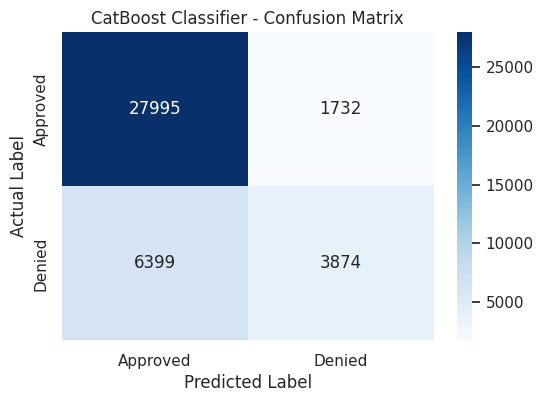

--- HistGradientBoosting Classifier Performance ---
Accuracy:  0.7954
Precision: 0.7805
Recall:    0.7954
F1 Score:  0.7736

Classification Report:
              precision    recall  f1-score   support

    Approved       0.81      0.94      0.87     29727
      Denied       0.68      0.38      0.49     10273

    accuracy                           0.80     40000
   macro avg       0.75      0.66      0.68     40000
weighted avg       0.78      0.80      0.77     40000



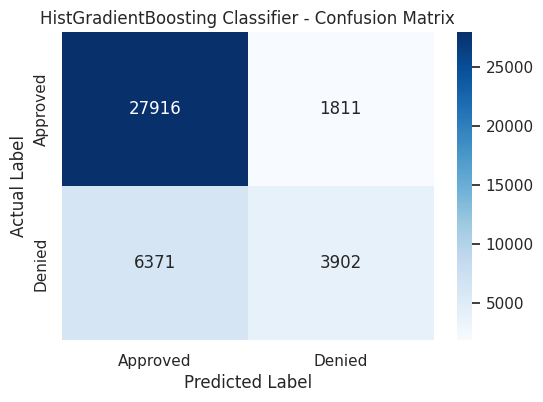

In [ ]:
def evaluateAndPlot(yTrue, yPred, modelName):
    acc = accuracy_score(yTrue, yPred)
    prec = precision_score(yTrue, yPred, average='weighted')
    rec = recall_score(yTrue, yPred, average='weighted')
    f1 = f1_score(yTrue, yPred, average='weighted')

    print(f"--- {modelName} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(yTrue, yPred, target_names=targetEncoder.classes_))

    cm = confusion_matrix(yTrue, yPred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=targetEncoder.classes_, yticklabels=targetEncoder.classes_)
    plt.title(f'{modelName} - Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

evaluateAndPlot(yTest, yPredCat, "CatBoost Classifier")
evaluateAndPlot(yTest, yPredHist, "HistGradientBoosting Classifier")

## Interpretability:
To make the model actionable, we visualize feature importance. This helps stakeholders understand which variables (e.g., specific payers, medical codes, or documentation scores) are the strongest predictors of denial risk.

/tmp/ipykernel_28718/1884794662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importanceDf.head(15), x='Importance', y='Feature', palette='viridis')


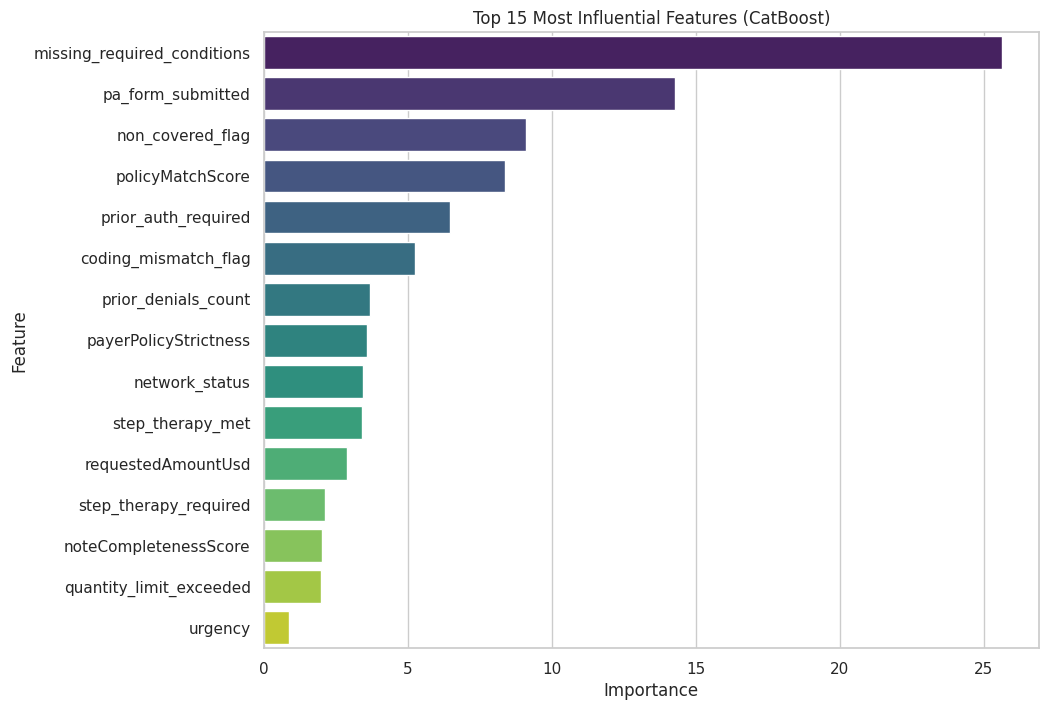

In [ ]:
featureImportance = catModel.get_feature_importance()
featureNames = X.columns
importanceDf = pd.DataFrame({'Feature': featureNames, 'Importance': featureImportance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importanceDf.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Influential Features (CatBoost)')
plt.show()